# 01 — Análise Exploratória (EDA)

**Sprint 1-2 · Credit Card Fraud Detection**

Este notebook é o "rascunho de investigação" que normalmente aconteceria **antes** de qualquer linha do `pipelines/feature_engineering.py` existir. Nos scripts `.py` do projeto, essas decisões (dropar `Time`, escalar só `Amount`, usar `stratify=y`) já chegam prontas — aqui vamos devagar, célula por célula, para entender **de onde** cada decisão veio.

**Regra de ouro deste notebook:** nunca vamos executar nada em cima do `data/processed/` (que já foi gerado pelo pipeline). Trabalhamos sempre a partir do CSV bruto em `data/raw/creditcard.csv`, como se nunca tivéssemos visto esse dataset antes.

**O que vamos responder aqui:**
1. Quão desbalanceado é o dataset, e por que isso importa desde já?
2. O que a coluna `Amount` parece, e por que ela (e só ela) precisa de escala?
3. O que a coluna `Time` esconde, e por que o pipeline de produção a descarta mesmo assim?
4. As colunas `V1`-`V28` têm alguma correlação óbvia com fraude?
5. Existem dados faltantes ou duplicados que precisam ser tratados?

Cada resposta vira uma decisão que você vai reconhecer depois em `feature_engineering.py` e `train.py`.


## Fluxo desta investigação

Cada etapa só faz sentido depois da anterior — se pularmos o balanceamento de classes, por exemplo, uma correlação que parece "fraca" pode na verdade ser a mais forte do dataset, só que diluída pela maioria esmagadora de casos legítimos.

```mermaid
flowchart TD
    A[Carregar CSV bruto] --> B[Balanceamento de classes]
    B --> C[Distribuição de Amount]
    C --> D[Time: esconde algo?]
    D --> E[Correlação V1-V28 vs Class]
    E --> F[Nulos e duplicados]
    F --> G[Decisões para feature_engineering.py]
```

Vamos manter esse pipeline mental: **olhar → interpretar → decidir**, nunca só rodar a célula e seguir em frente.


In [1]:
# pandas: manipular a tabela | numpy: operações numéricas
# matplotlib/seaborn: gráficos estáticos, os mesmos que o pipeline usa em produção
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Este notebook usa o kernel "mlops-lab (uv)", registrado com PYTHONUTF8=1 já
# no ambiente (make notebooks faz isso). Sem isso, print() com acento vira
# texto corrompido no Windows (cp1252 no console) — mesmo motivo pelo qual
# os scripts .py do projeto setam PYTHONUTF8 antes de importar mlflow/boto3.
# Se você trocar de kernel, troque de volta para "mlops-lab (uv)".

# %matplotlib inline: garante que os gráficos apareçam embutidos nas células
# (fora do notebook, o train.py usa matplotlib.use("Agg") porque não há tela nenhuma)
%matplotlib inline

sns.set_theme(style="whitegrid")  # grid discreto, mais fácil de ler valores

RAW_FILE = Path.cwd().parent / "data" / "raw" / "creditcard.csv"
RAW_FILE


WindowsPath('c:/Users/andre/Downloads/ProjetoClaudeGitHub/residencia-mle-mlops/mlops-lab/data/raw/creditcard.csv')

## 1. Carregar os dados brutos

Antes de qualquer transformação, olhamos a tabela exatamente como ela chegou do Kaggle — sem dropar `Time`, sem escalar `Amount`. É o mesmo arquivo que `download_data.py` valida por hash MD5.


In [2]:
df = pd.read_csv(RAW_FILE)

print(f"Shape: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
df.info()


Shape: 284,807 linhas x 31 colunas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     28480

**Leia o `df.info()` acima com atenção:**
- `284807 non-null` em toda coluna → já é um bom sinal de que não há nulos (vamos confirmar formalmente mais adiante, não confiar só nisso).
- `Time`, `Amount`, `V1`...`V28` são `float64`; `Class` é `int64` — o target já vem como 0/1, não como texto ("fraude"/"legítima"), então não precisamos codificar nada.
- 30 colunas de feature (`Time` + `Amount` + 28 `V`) + 1 de target (`Class`) = 31 no total.

Vamos ver as primeiras linhas para ter uma sensação visual dos valores:


In [3]:
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Repare que `V1`...`V28` têm valores tipo `-1.359807`, `0.072781` — nada com "cara" de valor de negócio (não é idade, não é CEP). Isso é porque **já são saída de PCA** (Principal Component Analysis): o dataset original tinha colunas sensíveis (localização, dados do cartão, do comerciante) que o Kaggle não podia publicar por privacidade, então elas foram compactadas nesses 28 componentes anônimos antes da publicação. Isso explica por que ninguém no projeto tenta "engenheirar" novas features a partir de V1-V28: já são o produto final de uma transformação que não podemos desfazer.

`Amount` e `Time`, ao contrário, chegaram intactos — por isso são os únicos dois candidatos a qualquer decisão de feature engineering daqui pra frente.

## 2. Balanceamento de classes

Esta é a pergunta mais importante do notebook inteiro — a resposta dela afeta literalmente todas as decisões dos próximos sprints (métrica de avaliação, `class_weight`, `stratify`).


Legítimas (0): 284,315  (99.827%)
Fraudes   (1):     492  (0.173%)
Razão: 1 fraude para cada 577 transações legítimas


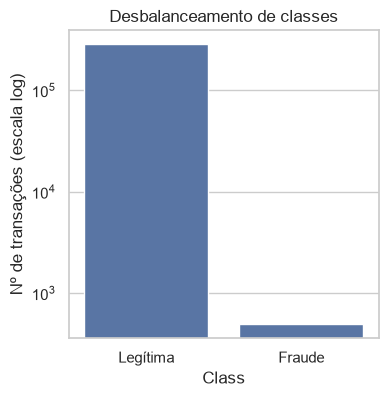

In [4]:
counts = df["Class"].value_counts()
pct = df["Class"].value_counts(normalize=True) * 100

print(f"Legítimas (0): {counts[0]:>7,}  ({pct[0]:.3f}%)")
print(f"Fraudes   (1): {counts[1]:>7,}  ({pct[1]:.3f}%)")
print(f"Razão: 1 fraude para cada {counts[0] // counts[1]:,} transações legítimas")

fig, ax = plt.subplots(figsize=(4, 4))
sns.barplot(x=counts.index.map({0: "Legítima", 1: "Fraude"}), y=counts.values, ax=ax)
ax.set_yscale("log")  # sem escala log a barra de fraude fica invisível ao lado da outra
ax.set_ylabel("Nº de transações (escala log)")
ax.set_title("Desbalanceamento de classes")
plt.show()


**Por que a escala log no gráfico:** numa escala linear normal, a barra de fraude ficaria tão pequena (0,17%) que pareceria zero — a escala log "estica" a diferença pra ela ficar visível, sem mentir sobre a proporção real.

**As 3 decisões que essa proporção (~1:577) já justifica, antes de qualquer modelo existir:**

| Decisão futura | Por quê |
|---|---|
| `train_test_split(..., stratify=y)` no Sprint 2 | Sem isso, um split aleatório "de sorte" pode isolar quase todas as ~492 fraudes no treino, deixando o teste sem exemplo nenhum pra avaliar |
| `class_weight="balanced"` no Sprint 3 | Um modelo "preguiçoso" que sempre prevê "legítima" já acerta 99,83% — sem penalizar mais o erro na classe rara, o modelo aprende a ignorá-la |
| PR-AUC como métrica principal, não ROC-AUC | ROC-AUC conta os verdadeiros negativos (a maioria esmagadora), então fica artificialmente alto mesmo com um modelo ruim em fraude. PR-AUC olha só pra classe positiva |

## 3. Distribuição de `Amount`


In [5]:
df["Amount"].describe()


count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

Repare a diferença entre `mean` (~88) e `50%`/mediana (~22): a média é bem maior que a mediana, o que já denuncia uma distribuição **assimétrica à direita** (poucas transações de valor muito alto puxando a média pra cima). Vamos visualizar:


C:\Users\andre\AppData\Local\Temp\ipykernel_21808\748805916.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(["Legítima", "Fraude"])


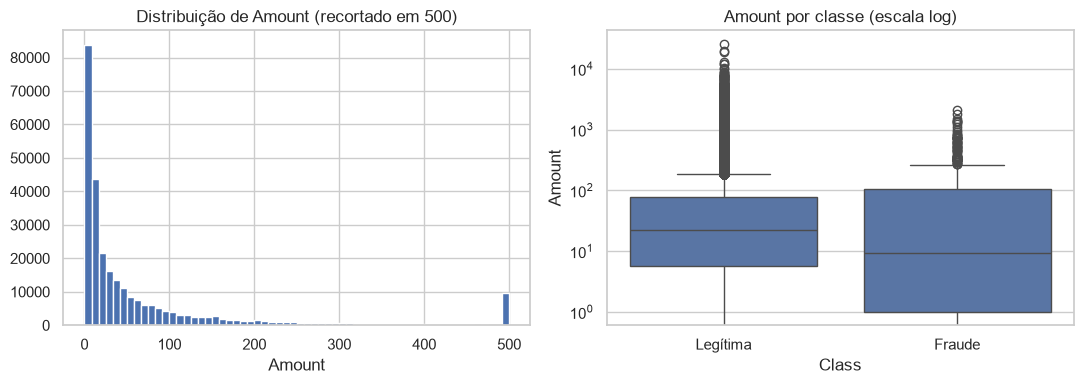

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Histograma: recorta em 500 pra não deixar os poucos outliers de valor alto
# esconderem a forma da distribuição no grosso dos dados
axes[0].hist(df["Amount"].clip(upper=500), bins=60)
axes[0].set_title("Distribuição de Amount (recortado em 500)")
axes[0].set_xlabel("Amount")

# Boxplot lado a lado por classe: é aqui que perguntamos
# "fraudes tendem a ter valores diferentes de transações normais?"
sns.boxplot(data=df, x="Class", y="Amount", ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_xticklabels(["Legítima", "Fraude"])
axes[1].set_title("Amount por classe (escala log)")

plt.tight_layout()
plt.show()


**Duas leituras deste gráfico:**
1. **Histograma:** a maioria das transações tem valor baixo (concentração perto de 0), com uma cauda longa de valores altos — típico de dados de dinheiro (poucas compras muito caras, muitas baratas).
2. **Boxplot por classe:** as medianas de `Amount` para fraude e legítima não são drasticamente diferentes — ou seja, **`Amount` sozinho não separa bem as classes**. Isso é uma pista de que o modelo vai depender muito mais das colunas `V1`-`V28` do que de `Amount` para decidir.

**Por que só `Amount` é escalado (e `V1`-`V28` não) em `feature_engineering.py`:** `V1`-`V28` já saíram do PCA em escala parecida (a técnica de PCA já normaliza como parte do processo). `Amount`, como vimos, varia de ~0 a milhares — sem escalar, ele dominaria qualquer cálculo de distância ou regularização do modelo só por ter números maiores, não por ser mais importante.

## 4. O que `Time` esconde


O `feature_engineering.py` faz `df.drop(columns=["Time"])` logo de cara, com o comentário "baixo poder preditivo bruto". Vamos verificar essa afirmação em vez de aceitar de olhos fechados.

`Time` é "segundos desde a primeira transação do dataset" — um número bruto tipo `472` não significa nada sozinho. Mas se convertermos pra **hora do dia**, vira algo interpretável:


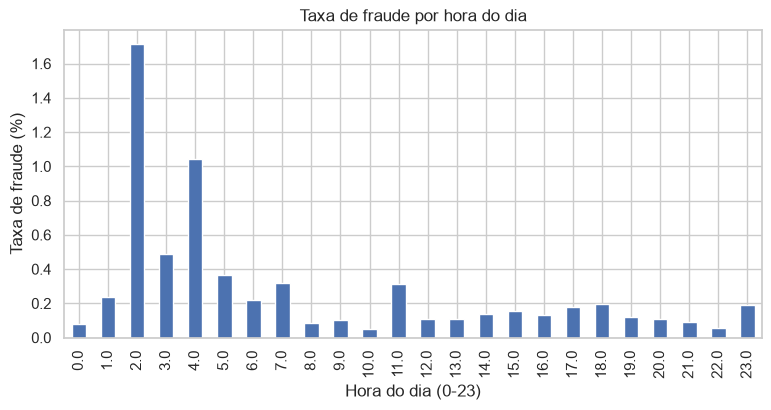

In [7]:
# Time é contínuo em segundos ao longo de ~2 dias de coleta.
# % (3600 * 24) traz de volta pra um relógio de 0-24h, ignorando em qual dos 2 dias caiu.
hour = (df["Time"] % (3600 * 24)) // 3600

fraud_rate_by_hour = df.groupby(hour)["Class"].mean() * 100

fig, ax = plt.subplots(figsize=(9, 4))
fraud_rate_by_hour.plot(kind="bar", ax=ax)
ax.set_xlabel("Hora do dia (0-23)")
ax.set_ylabel("Taxa de fraude (%)")
ax.set_title("Taxa de fraude por hora do dia")
plt.show()


**Execute a célula acima e olhe as barras: elas são parecidas entre si, ou algumas horas se destacam bem mais que outras?** Nesse dataset é conhecido que a taxa de fraude tende a subir nas horas de madrugada — não porque haja mais fraude em número absoluto, mas porque o volume de transações **legítimas** despenca de madrugada e a fraude não segue o mesmo ritmo, então a *proporção* sobe.

**Isso contradiz o comentário `# baixo poder preditivo bruto` do pipeline?** Não exatamente — o comentário está certo sobre `Time` *bruto* (o segundo exato não ajuda em nada). Mas ele esconde uma decisão que o projeto nunca chegou a testar: **`Time` convertido em hora-do-dia poderia ser uma feature nova**, não aproveitada. Isso é uma lacuna real do projeto, não um erro — é um trade-off consciente de manter o pipeline simples (Sprint 2 já tinha bastante coisa nova: split estratificado, escala, Parquet) em vez de perseguir cada ponto percentual de ganho.

**Ponto de entrevista:** se te perguntarem "que melhoria você faria nesse pipeline?", essa é uma resposta concreta e defensável.

## 5. Correlação de `V1`-`V28` com `Class`


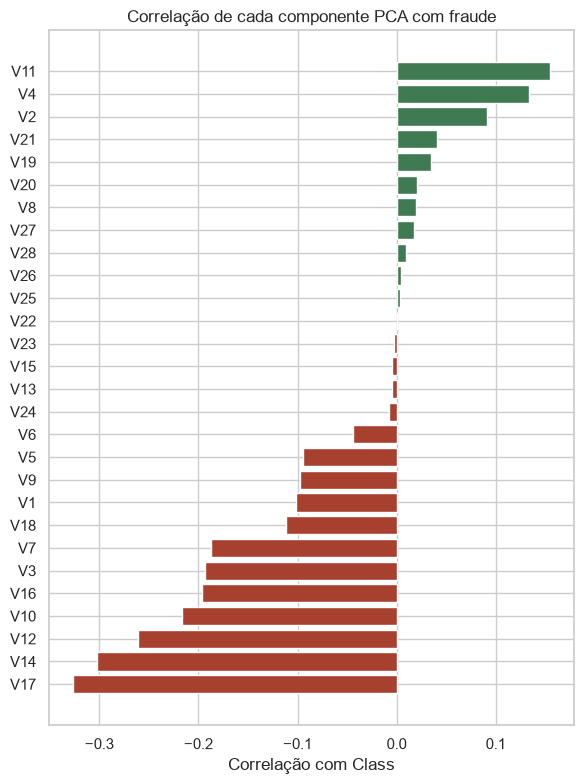

Top 5 mais correlacionadas (em módulo):
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
Name: Class, dtype: float64


In [8]:
v_cols = [f"V{i}" for i in range(1, 29)]

# Correlação de cada V com Class — não a matriz inteira (28x28 seria ilegível
# e não é a pergunta que queremos responder aqui)
corr_with_class = df[v_cols + ["Class"]].corr()["Class"].drop("Class").sort_values()

fig, ax = plt.subplots(figsize=(6, 8))
colors = ["#a8402f" if v < 0 else "#3f7a52" for v in corr_with_class.values]
ax.barh(corr_with_class.index, corr_with_class.values, color=colors)
ax.set_xlabel("Correlação com Class")
ax.set_title("Correlação de cada componente PCA com fraude")
plt.tight_layout()
plt.show()

print("Top 5 mais correlacionadas (em módulo):")
print(corr_with_class.abs().sort_values(ascending=False).head())


**Como ler isso:** correlação de Pearson mede relação *linear*, de -1 a +1. Barras vermelhas (negativas) significam "quando esse componente sobe, a chance de fraude cai"; verdes (positivas), o contrário. O que importa aqui não é o sinal, é o **tamanho da barra** — quanto mais longe de 0, mais essa variável sozinha se move junto com a fraude.

Componentes com barra grande (positiva ou negativa) são as que, isoladamente, mais separam as duas classes — e por isso tendem a aparecer no topo da lista de `feature_importances_` quando treinarmos a Random Forest no Sprint 3. Isso te dá uma forma de **validar** o modelo depois: se a importância das features do modelo treinado bater com essa correlação simples, é bom sinal de que ele aprendeu um padrão real, não ruído.

**Por que não fizemos uma matriz de correlação 28x28 completa:** ela existe, mas 28x28 = 784 números numa única imagem é ilegível e não responde à pergunta que fizemos ("o que se relaciona com fraude?"). É uma escolha de visualização: sempre comece pela pergunta, não pelo gráfico mais "completo" possível.

## 6. Nulos e duplicados


In [9]:
n_nulls = df.isna().sum().sum()
n_duplicates = df.duplicated().sum()

print(f"Valores nulos no dataset inteiro : {n_nulls}")
print(f"Linhas 100% duplicadas            : {n_duplicates} ({n_duplicates / len(df) * 100:.2f}%)")

if n_duplicates:
    print("\nQuantas dessas duplicatas são fraude?")
    print(df[df.duplicated()]["Class"].value_counts())


Valores nulos no dataset inteiro : 0
Linhas 100% duplicadas            : 1081 (0.38%)

Quantas dessas duplicatas são fraude?
Class
0    1062
1      19
Name: count, dtype: int64


**Nulos:** este dataset historicamente não tem nenhum — o `df.info()` já sugeria isso lá no início, e aqui confirmamos com uma checagem explícita e formal (`isna().sum()`), em vez de confiar só na leitura visual.

**Duplicatas:** este é o achado mais importante desta seção, e **nem `feature_engineering.py` nem `train.py` tratam isso** — nenhum dos dois chama `drop_duplicates()` antes do split. O risco concreto: se uma linha duplicada cair no treino *e* no teste ao mesmo tempo (perfeitamente possível, já que o split é aleatório sobre o dataset inteiro), o modelo é avaliado em parte com dados que ele literalmente já viu — inflando a métrica de teste sem que o modelo tenha realmente generalizado melhor.

**Isso não é a mesma coisa que o data leakage do Sprint 2** (`fit` no teste) — aqui o vazamento é de *linhas*, não de *estatística*. Mas o efeito prático é parecido: a métrica de teste fica um pouco otimista demais.

**Ponto de entrevista:** outra lacuna real e defensável — "o pipeline não deduplica antes do split; eu adicionaria `df.drop_duplicates()` logo após o load, antes de qualquer split."

## Conclusão — o que este notebook decide, e como isso vira código


| O que vimos aqui | Onde isso vira código de produção |
|---|---|
| Desbalanceamento ~1:578 | `stratify=y` (Sprint 2) + `class_weight="balanced"` e PR-AUC (Sprint 3) |
| `Amount` assimétrico, sem separar bem as classes sozinho | `StandardScaler()` só em `Amount`, dentro do `Pipeline` (Sprints 2 e 3) |
| `Time` bruto sem sinal, mas hora-do-dia pode ter sinal não explorado | Pipeline dropa `Time` inteiro — **melhoria não implementada** |
| Algumas `V` bem mais correlacionadas que outras | Nenhuma seleção de features é feita — todas as 28 seguem pro modelo, e a Random Forest decide a importância sozinha |
| Sem nulos, mas com duplicatas não tratadas | **Gap real do pipeline** — `drop_duplicates()` nunca é chamado |

### Perguntas de validação

1. Por que usamos escala **log** no gráfico de desbalanceamento de classes, e por que isso não "engana" a leitura dos dados?
2. Se você removesse a linha `stratify=y` do split, que problema concreto poderia aparecer no teste?
3. Por que `V1`-`V28` não são escaladas, mas `Amount` é?
4. Que decisão o pipeline atual toma sobre `Time` que este notebook questiona, e qual seria a alternativa?
5. Qual a diferença entre o vazamento de dados do Sprint 2 (`fit` no teste) e o problema de duplicatas encontrado aqui?

Quando estiver confortável com essas 5 respostas, seguimos para o **notebook 02 — Feature Engineering**, onde vamos construir o `Pipeline` de pré-processamento célula por célula (não só chamar a função pronta).
